# Principal Component Analysis (advanced)
In this example, we will use the Zarr stores to examine the modes of speed variability at a glacier on the Antarctica Peninsula. 

It is now well known that glaciers along the west coast of the Antarctic Peninsula undergo seasonal changes in speed. This has been shown through the presentation of speed timeseries extracted in Eulerian reference frame from fixed locations relatively close (a few kilometres upstream) to glacier termini. The interpretation of the resulting timeseries is muddied somewhat because glacier terminus position also varies seasonally, which means that the distance between the fixed extraction location and the moving glacier terminus varies seasonally. On glaciers with steep gradients in speed near the terminus (i.e. most glaciers), this extraction strategy could alias speed gradients as temporal variations in ice speed - as the terminus retreats in summer, faster speeds will be recorded at the extraction location which is now closer to the terminus. 

Of course, the most direct way to avoid aliasing would be to migrate the extraction location up- or downstream as the terminus retreats or advances. However, terminus position delineation is the devil's own job and even the most enthusiastic digitiser would (should!) baulk at the idea of digitising every glacier terminus around the Antarctic Peninsula every week since 2015 (when imagery became frequent enough to resolve seasonal speed changes). 

One way to help clarify this interpretation is to examine how glacier speed changes (seasonally or over some other timescale) across the whole glacier. Perhaps the simplest way to do that is to extract speed data along a flowline - i.e. examine multiple timeseries a different distances upstream. However, with relatively complete velocity data, we can go a step further and perform a Principal Component Analysis (PCA) on the data.

If you are unfamiliar with PCA and related analysis, Ashmore et al. (2021) presents a compelling example of its utility when applied to a fast-flowing glacier in west Greenland and Chad Greene produced a great introduction to Empirical Orthogonal Functions (EOFs) in MATLAB [here](https://www.chadagreene.com/CDT/eof_documentation.html). 

> Ashmore, D.W., Mair, D.W., Higham, J.E., Brough, S., Lea, J.M. and Nias, I.J., 2022. Proper orthogonal decomposition of ice velocity identifies drivers of flow variability at Sermeq Kujalleq (Jakobshavn Isbræ). The Cryosphere, 16, 219-236. DOI: https://doi.org/10.5194/tc-16-219-2022

Let's setup our work station to do this.

In [1]:
import sys
import xarray as xr
import rioxarray
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter, detrend
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from matplotlib_scalebar.scalebar import ScaleBar
import zarr
import cmcrameri.cm as cmc
from dask.distributed import Client, LocalCluster

# Spin up a local Dask cluster
cluster = LocalCluster(n_workers=4, threads_per_worker=2)
client = Client(cluster)

# Cap Zarr's internal HTTP concurrency per worker
zarr.config.set({"async.concurrency": 2})

print(f"Dask Dashboard link: {client.dashboard_link}")

Dask Dashboard link: http://127.0.0.1:8787/status


### 1. Configuration and Parameters

First, we need to set up our paths, processing parameters, and quality thresholds. 

Because PCA is highly sensitive to noise and missing data, we define thresholds here to mask out pixels that have too many data gaps (`MAX_PROP_FILLED`, `MAX_GAP_ALLOWED`). We also define our Savitzky-Golay smoothing windows, which we will use to gently interpolate through periods of missing data without significantly modifying real changes in speed over longer timescales.

In [2]:
# --- CONFIGURATION ---
TARGET_BASIN = "Leonardo Glacier"

# Paths
AUX_DIR = Path(r"/no/one/wants/to/see/my/directory/structure/aux_data")
ZARR_PATH = "s3://us-west-2.opendata.source.coop/uos-shiver/antarctica/antarctica_multisource_velocity_cubed.zarr"
BASINS_PATH = AUX_DIR / "NEB_Basins_reproject_fixed.shp"

ROCK_MASK_PATH = AUX_DIR / "rock_mask_Antarctica_EPSG3031_30m_peninsula.tif"
ICE_MASK_PATH = AUX_DIR / "ice_mask_peninsula_EPSG3031_200m.tif"
BEDMACHINE_PATH = AUX_DIR /  "BedMachine_mask.tif"
BEDMAP3_PATH = AUX_DIR /  "BedMap3_mask.tif"
DEM_PATH = "/no/one/wants/to/see/my/directory/structure/REMA_100m_peninsula_dem_filled.tif"
GL_PATH = "/no/one/wants/to/see/my/directory/structure/AP_GL_TMOC_2019_2020.shp"

# VELOCITY REFERENCE MAPS - I precomputed these to make the code easier to digest
U_PATH = AUX_DIR / "U_median_20141125_20250805_200m_raw.tif"
V_PATH = AUX_DIR / "V_median_20141125_20250805_200m_raw.tif"
S_PATH = AUX_DIR / "S_median_20141125_20250805_200m_raw.tif"

# --- PROCESSING PARAMETERS ---
# Let's focus on a period where velocity data are frequent enough to give us a chance of resolving seasonality
START_DATE = '2016-10-01'
END_DATE = '2025-03-01'
PCA_FREQ = '12D'     
NUM_MODES = 3   # Restricted to first 3 modes
MIN_MEAN_SPEED = 80   

# --- DUAL SMOOTHING & FILLING ---
PRE_FILL_LIMIT = 24   
SAVGOL_WINDOW_PRE = 25 
SAVGOL_WINDOW_POST = 35 
SAVGOL_POLY = 2

# --- PCA QUALITY MASKING ---
MAX_PROP_FILLED = 0.75  
MAX_GAP_ALLOWED = 150

### 2. Helper Functions

Next, we define a few helper functions to keep our main processing blocks clean. This includes a custom colormap function that centres around zero (crucial for visualising PCA anomalies where positive and negative values represent opposite phases of a signal), a function to calculate the maximum consecutive data gap for quality control, and our plotting routines.

In [3]:
def get_clim_and_cmap(data_values):
    valid = data_values[~np.isnan(data_values)]
    if len(valid) == 0:
        return 'RdBu_r', -1, 1 
    
    p5, p95 = np.nanpercentile(valid, [5, 95])
    
    if cmc is None: 
        cmap = 'RdBu_r'
        vmax = max(abs(p5), abs(p95))
        vmin = -vmax
    else:
        is_positive = p5 >= 0
        is_negative = p95 <= 0
        
        if is_positive:
            cmap = cmc.bilbao_r
            vmin, vmax = p5, p95
        elif is_negative:
            cmap = cmc.lapaz_r
            vmin, vmax = p5, p95 
        else:
            cmap = cmc.vik
            limit = max(abs(p5), abs(p95))
            vmin = -limit
            vmax = limit
            
    return cmap, vmin, vmax

def calc_max_gap_1d(data_1d):
    valid_indices = np.flatnonzero(~np.isnan(data_1d))
    total_len = len(data_1d)
    
    if len(valid_indices) == 0:
        return total_len 
    
    max_internal = 0
    if len(valid_indices) > 1:
        max_internal = np.max(np.diff(valid_indices)) - 1
        
    start_gap = valid_indices[0]
    end_gap = (total_len - 1) - valid_indices[-1]
    
    return max(max_internal, start_gap, end_gap)

def plot_quality_map(prop_filled_da, max_gap_da, dem_da, basin_geom, glacier_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    ls = LightSource(azdeg=315, altdeg=45)
    dem_filled = dem_da.fillna(0).values
    hillshade = ls.hillshade(dem_filled, vert_exag=1)
    
    # Panel 1: Proportion Filled
    ax = axes[0]
    ax.imshow(hillshade, cmap='gray', extent=[dem_da.x.min(), dem_da.x.max(), dem_da.y.min(), dem_da.y.max()], origin='upper')
    im1 = prop_filled_da.plot(ax=ax, cmap='viridis', vmin=0, vmax=1, alpha=0.8, add_colorbar=False)
    gpd.GeoSeries([basin_geom]).plot(ax=ax, facecolor='none', edgecolor='white', linewidth=1.5)
    plt.colorbar(im1, ax=ax, label="Proportion Interpolated (0-1)", orientation='horizontal', pad=0.05)
    ax.set_title(f"Metric 1: Proportion Synthetic\n(Threshold > {MAX_PROP_FILLED})")

    # Panel 2: Max Gap
    ax = axes[1]
    ax.imshow(hillshade, cmap='gray', extent=[dem_da.x.min(), dem_da.x.max(), dem_da.y.min(), dem_da.y.max()], origin='upper')
    im2 = max_gap_da.plot(ax=ax, cmap='magma', vmin=0, vmax=365, alpha=0.8, add_colorbar=False)
    gpd.GeoSeries([basin_geom]).plot(ax=ax, facecolor='none', edgecolor='white', linewidth=1.5)
    plt.colorbar(im2, ax=ax, label="Max Consecutive Gap (Days)", orientation='horizontal', pad=0.05)
    ax.set_title(f"Metric 2: Max Gap\n(Threshold > {MAX_GAP_ALLOWED} days)")

    plt.suptitle(f"{glacier_name}: PCA Input Quality Masks", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_mode_figure(mode_num, pct_var, pc_series, eof_map_da, dem_da, gl_gdf, basin_geom, glacier_name):
    fig = plt.figure(figsize=(12, 6), constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1])
    
    # Panel 1: Time Series
    ax_ts = fig.add_subplot(gs[0])
    dates = pd.to_datetime(pc_series.time.values)
    vals = pc_series.values
    
    ax_ts.axhline(0, color='k', linewidth=0.5)
    ax_ts.fill_between(dates, vals, 0, where=(vals >= 0), facecolor='red', alpha=0.6, interpolate=True)
    ax_ts.fill_between(dates, vals, 0, where=(vals <= 0), facecolor='blue', alpha=0.6, interpolate=True)
    ax_ts.plot(dates, vals, color='k', linewidth=0.8)
    ax_ts.set_ylabel("Normalized Amplitude (Max=1)")
    ax_ts.grid(True, linestyle=':', alpha=0.5)
    ax_ts.set_xlim(pd.to_datetime(START_DATE), pd.to_datetime(END_DATE))

    # Panel 2: Spatial Map
    ax_map = fig.add_subplot(gs[1])
    ax_map.set_aspect('equal')
    
    ls = LightSource(azdeg=315, altdeg=45)
    dem_filled = dem_da.fillna(0).values
    hillshade = ls.hillshade(dem_filled, vert_exag=1)
    ax_map.imshow(hillshade, cmap='gray', extent=[dem_da.x.min(), dem_da.x.max(), dem_da.y.min(), dem_da.y.max()], origin='upper')

    vals_flat = eof_map_da.values.flatten()
    cmap_name, vmin, vmax = get_clim_and_cmap(vals_flat)

    if cmap_name == cmc.vik or cmap_name == 'RdBu_r':
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    im = eof_map_da.plot(ax=ax_map, cmap=cmap_name, norm=norm, add_colorbar=False, alpha=0.9, zorder=2)

    brown_rgb = np.array([150, 75, 0]) / 255.0
    levels_all = np.arange(0, 3000, 100)
    levels_solid = [l for l in levels_all if l < 700 or l > 1500]
    levels_trans = [l for l in levels_all if 700 <= l <= 1500]
    
    if levels_solid:
        ax_map.contour(dem_da.x, dem_da.y, dem_da, levels=levels_solid, colors=[brown_rgb], linewidths=0.5, alpha=1.0, zorder=3)
    if levels_trans:
        ax_map.contour(dem_da.x, dem_da.y, dem_da, levels=levels_trans, colors=[brown_rgb], linewidths=0.5, alpha=0.3, zorder=3)

    if not gl_gdf.empty:
        gl_gdf.plot(ax=ax_map, color='magenta', linewidth=1.5, zorder=5)
    gpd.GeoSeries([basin_geom]).plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=1.5, zorder=5)

    def fmt_km(x, pos): return f"{x/1000:.0f}"
    ax_map.xaxis.set_major_formatter(fmt_km)
    ax_map.yaxis.set_major_formatter(fmt_km)
    ax_map.set_xlabel("Easting (km)")
    ax_map.set_ylabel("Northing (km)")
    ax_map.add_artist(ScaleBar(1, units="m", location="lower right", box_alpha=0.5))

    plt.colorbar(im, ax=ax_map, orientation='horizontal', pad=0.1, label="EOF (m/yr)")
    
    ax_map.set_title("")
    ax_ts.set_title("")
    fig.suptitle(f"{glacier_name}: Mode {mode_num} ({pct_var:.1f}%)", fontsize=14, fontweight='bold')
    plt.show()

### 3. Data Loading and Time Separations

Now we connect to the Zarr store. 

As has been mentioned earlier in this book, one important quirk of satellite-derived velocity data is that each velocity map represents an *average* speed over a specific time window (the time between two satellite acquisitions), not an instantaneous snapshot. To accurately map this data to a daily timeseries, we need to know account for that time separation. 

We extract this time separation from the `time_bnds` variable then clip the data to our target glacier basin and load it into memory.

In [4]:
# 1. Load Basin Geometry
all_basins = gpd.read_file(BASINS_PATH)
basin_row = all_basins[all_basins['name'] == TARGET_BASIN].iloc[0]
basin_geom = basin_row.geometry

print(f"Loaded geometry for {TARGET_BASIN}")

# 2. Configure HTTP Backend for S3
s3_options = {
    "anon": True, 
    "config_kwargs": {
        "max_pool_connections": 50,  
        "retries": {
            "max_attempts": 10,      
            "mode": "standard"       
        }
    }
}

# 3. Open Zarr Store & Filter for SHIFT
print("Connecting to Zarr store...")
ds = xr.open_dataset(ZARR_PATH, engine="zarr", storage_options=s3_options, chunks='auto')

if "data_source" in ds.coords or "data_source" in ds.dims:
    ds = ds.sel(data_source="SHIFT")

if ds.rio.crs is None: 
    ds.rio.write_crs("EPSG:3031", inplace=True)

# Slice by time first
ds = ds.sortby('time').sel(time=slice(START_DATE, END_DATE))

# Extract time_bnds and calculate separation 
print("Extracting time bounds...")
tb = ds['time_bnds'].load()  # Load just the time_bnds into memory
time_diff = tb.isel({tb.dims[-1]: 1}) - tb.isel({tb.dims[-1]: 0})
raw_seps_da = (time_diff / np.timedelta64(1, 'D')).fillna(12)
raw_seps = raw_seps_da.values

# 4. clip to basin and load into memory
print("Clipping to basin and loading into memory...")
clipped = ds.rio.clip_box(*basin_geom.bounds).rio.clip([basin_geom], all_basins.crs, drop=True, all_touched=True)
clipped = clipped.load()
print(f"Data successfully loaded into memory: {clipped.sizes}")

Loaded geometry for Leonardo Glacier
Connecting to Zarr store...
Extracting time bounds...
Clipping to basin and loading into memory...


C:\Users\gg1bjd\AppData\Local\anaconda3\envs\shiver_env\Lib\site-packages\distributed\client.py:3429: UserWarning: Sending large graph of size 49.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Data successfully loaded into memory: Frozen({'time': 2203, 'x': 65, 'y': 51})


### 4. Temporal Distribution and Gap Filling

**Why gap filling is necessary for PCA:**
Standard Principal Component Analysis requires a continuous, complete data matrix. It works by computing the covariance between every single pixel across time. If even a single `NaN` (missing value) exists in a pixel's timeseries, the algorithm cannot compute the covariance, and that pixel must be dropped entirely. 

Given that optical and radar satellite data are inherently gappy due to cloud cover, polar night and changes to surface conditions between image acquisitons, a raw velocity timeseries is riddled with missing data (and sometimes data that really ought to be missing). If we ran PCA on raw data, we would likely be left with zero valid pixels.

To ensure our computation works, we perform a three-step pre-processing pipeline:
1. **Temporal Distribution:** We take the multi-day average speed from the satellite and distribute it evenly across a daily grid for the duration of the image pair's time separation.
2. **Linear Interpolation:** We fill small gaps linearly to provide a baseline for the filter.
3. **Dual-Phase Savitzky-Golay Filtering:** We apply a smoothing filter that acts as a low-pass filter, retaining the broader seasonal/multi-annual signals while smoothing over short-term high-frequency noise and filling the remaining gaps with dynamically sound estimates. Finally, we downsample to a manageable frequency (e.g., 12 days) to speed up the PCA math.

In [5]:
# Extract target speed 
raw_s = clipped['speed']

target_dates = pd.date_range(START_DATE, END_DATE, freq='D')
ny, nx = raw_s.shape[1], raw_s.shape[2]
daily_sum = np.zeros((len(target_dates), ny, nx), dtype=np.float32)
daily_count = np.zeros((len(target_dates), ny, nx), dtype=np.int16)

raw_times = pd.to_datetime(raw_s.time.values)
target_date_map = {d: i for i, d in enumerate(target_dates)}

print("Distributing multi-day averages to daily grid...")
for t_idx, t_val in enumerate(raw_times):
    sep_days = raw_seps[t_idx]
    half_window = pd.Timedelta(days=sep_days/2)
    start_d = (t_val - half_window).floor('D')
    end_d = (t_val + half_window).ceil('D')
    
    start_target = max(start_d, target_dates[0])
    end_target = min(end_d, target_dates[-1])
    if start_target > end_target: continue
    
    idx_start = target_date_map.get(start_target)
    idx_end = target_date_map.get(end_target)
    
    if idx_start is not None and idx_end is not None:
        slice_data = raw_s.values[t_idx, :, :]
        valid_mask = ~np.isnan(slice_data)
        if not np.any(valid_mask): continue
        
        safe_data = np.nan_to_num(slice_data, nan=0.0)
        daily_sum[idx_start : idx_end + 1, :, :] += safe_data
        daily_count[idx_start : idx_end + 1, :, :] += valid_mask

with np.errstate(divide='ignore', invalid='ignore'):
    daily_dense = daily_sum / daily_count
    
da_daily = xr.DataArray(daily_dense, coords={"time": target_dates, "y": raw_s.y, "x": raw_s.x}, dims=("time", "y", "x"))

# Quality Metrics
print("Calculating quality metrics...")
is_missing = np.isnan(da_daily)
prop_filled_map = is_missing.sum(dim='time') / is_missing.sizes['time']

max_gap_map = xr.apply_ufunc(
    calc_max_gap_1d, da_daily, input_core_dims=[['time']], vectorize=True, output_dtypes=[np.float32]
)

# Savitzky-Golay Filtering
print("Running Phase 1 Smoothing...")
da_pre_fill = da_daily.interpolate_na(dim='time', method='linear', limit=PRE_FILL_LIMIT)

def smooth_pre(data):
    if np.isnan(data).any(): return data 
    if len(data) < SAVGOL_WINDOW_PRE: return data
    win = SAVGOL_WINDOW_PRE if SAVGOL_WINDOW_PRE % 2 == 1 else SAVGOL_WINDOW_PRE + 1
    return savgol_filter(data, window_length=win, polyorder=SAVGOL_POLY)

da_pre_smooth = xr.apply_ufunc(smooth_pre, da_pre_fill, input_core_dims=[['time']], output_core_dims=[['time']], vectorize=True, output_dtypes=[np.float32])
da_pre_smooth['time'] = da_daily['time']

# Fill gaps
da_full_fill = da_pre_smooth.interpolate_na(dim='time', method='linear', limit=None).bfill(dim='time').ffill(dim='time')

print("Running Phase 3 Smoothing...")
def smooth_post(data):
    if np.isnan(data).any(): return data
    if len(data) < SAVGOL_WINDOW_POST: return data
    win = SAVGOL_WINDOW_POST if SAVGOL_WINDOW_POST % 2 == 1 else SAVGOL_WINDOW_POST + 1
    return savgol_filter(data, window_length=win, polyorder=SAVGOL_POLY)

da_final_smooth = xr.apply_ufunc(smooth_post, da_full_fill, input_core_dims=[['time']], output_core_dims=[['time']], vectorize=True, output_dtypes=[np.float32])
da_final_smooth['time'] = da_daily['time']

# resample to PCA_FREQ (e.g. 12 days)
da_pca = da_final_smooth.resample(time=PCA_FREQ).mean()
print("Pre-processing complete.")

Distributing multi-day averages to daily grid...
Calculating quality metrics...
Running Phase 1 Smoothing...
Running Phase 3 Smoothing...
Pre-processing complete.


### 5. Diagnostic Check: Verifying the pre-processing

Before throwing our data into the PCA "black box", it is good practice to visually verify that our gap-filling and smoothing pipeline hasn't destroyed the underlying physical signal. 

In this cell, we extract the data for a specific point on the glacier (within a 250 m radius). We will plot the raw, gappy satellite measurements against our continuous, smoothed timeseries. 

We also calculate and subtract the **linear trend**. So that the PCA focuses on on the *oscillatory anomalies*, such as the seasonal pulses and short-term variations we are actually interested in. This is arguably less important for short time-series such as this, but its crucial when working with longer timeseries.

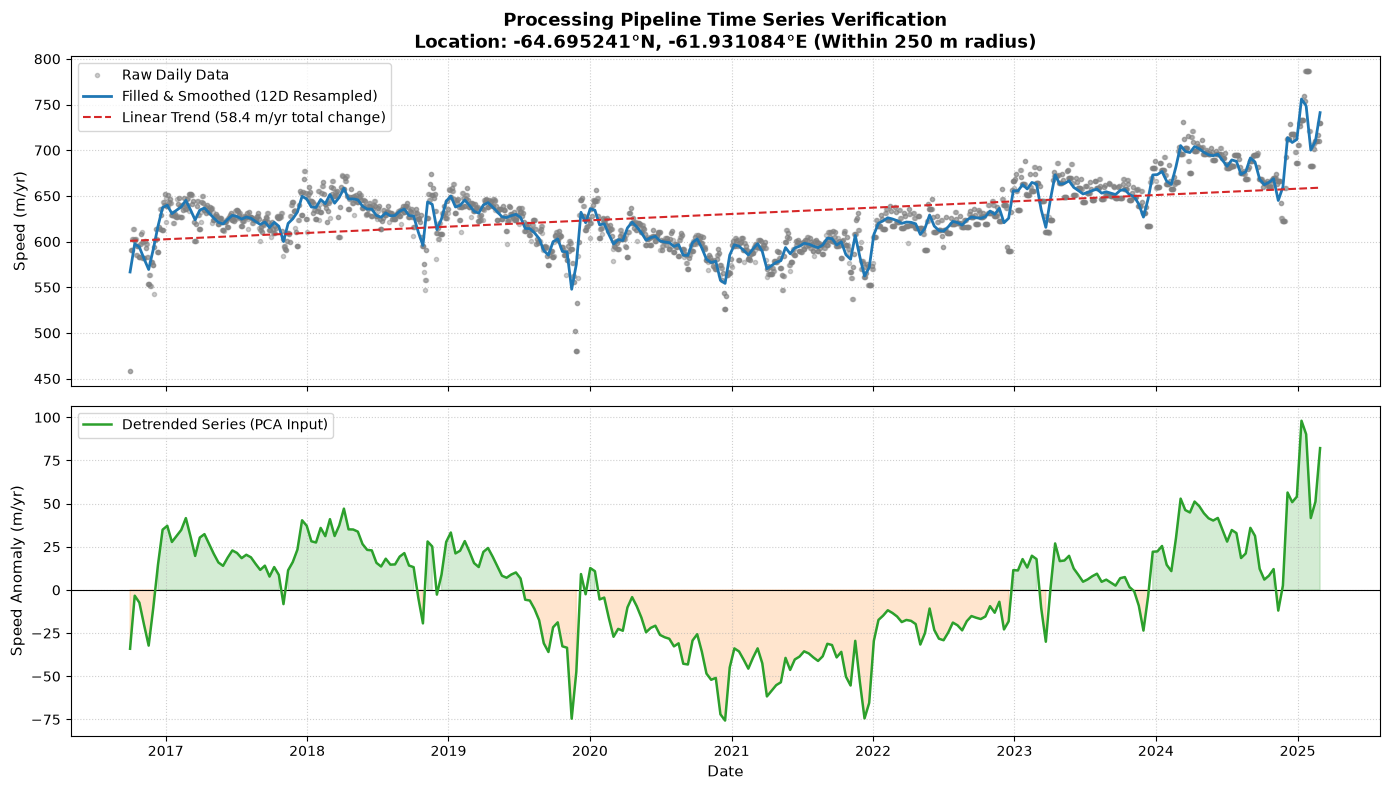

In [6]:
from pyproj import Transformer

# 1. Coordinates
target_lat = -64.695241
target_lon = -61.931084

# Reproject to EPSG:3031
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
target_x, target_y = transformer.transform(target_lon, target_lat)

# 2. Extract pixels in ROI
dist = np.sqrt((da_pca.x - target_x)**2 + (da_pca.y - target_y)**2)
radius_mask = dist <= 250

# Fallback to nearest pixel if needed (helpful if buffer is small)
if not bool(radius_mask.any()):
    radius_mask = (dist == dist.min())

# 3. Compute spatial mean for each stage
# Stage A: raw daily data
ts_raw_daily = da_daily.where(radius_mask).mean(dim=('y', 'x'))

# Stage B: filled, smoothed & resampled data (da_pca)
ts_filled_pca = da_pca.where(radius_mask).mean(dim=('y', 'x'))

# Stage C: linear trend and detrended data
filled_vals = ts_filled_pca.values
time_indices = np.arange(len(filled_vals))
valid_mask = ~np.isnan(filled_vals)

if np.any(valid_mask):
    # Fit linear trend to the filled time series
    slope, intercept = np.polyfit(time_indices[valid_mask], filled_vals[valid_mask], 1)
    linear_trend = slope * time_indices + intercept
    ts_detrended = filled_vals - linear_trend
else:
    slope = 0
    linear_trend = np.full_like(filled_vals, np.nan)
    ts_detrended = np.full_like(filled_vals, np.nan)

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- raw vs. filled & linear trend ---
ax1.plot(ts_raw_daily.time, ts_raw_daily, 'o', color='gray', alpha=0.4, markersize=3, label='Raw Daily Data')
ax1.plot(ts_filled_pca.time, ts_filled_pca, color='tab:blue', linewidth=2, label=f'Filled & Smoothed ({PCA_FREQ} Resampled)')
ax1.plot(ts_filled_pca.time, linear_trend, '--', color='tab:red', linewidth=1.5, label=f'Linear Trend ({slope*len(time_indices):.1f} m/yr total change)')

ax1.set_ylabel("Speed (m/yr)", fontsize=11)
ax1.set_title(f"Processing Pipeline Time Series Verification\nLocation: {target_lat:.6f}°N, {target_lon:.6f}°E (Within 250 m radius)", fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', frameon=True)

# --- detrended anomaly series (input to pCA) ---
ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax2.plot(ts_filled_pca.time, ts_detrended, color='tab:green', linewidth=1.8, label='Detrended Series (PCA Input)')
ax2.fill_between(ts_filled_pca.time, ts_detrended, 0, where=(ts_detrended >= 0), color='tab:green', alpha=0.2)
ax2.fill_between(ts_filled_pca.time, ts_detrended, 0, where=(ts_detrended < 0), color='tab:orange', alpha=0.2)

ax2.set_ylabel("Speed Anomaly (m/yr)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

### 6. Masking, Detrending, and Principal Component Analysis

Now for the heavy lifting. We apply several masks to ensure we are only analyzing valid ice. We mask out rock outcrops, the ocean (using BedMachine and Bedmap3), areas moving too slowly to yield a reliable signal-to-noise ratio, and any pixels that required *too much* synthetic gap-filling based on the thresholds we set above.

Once the data is clean, we flatten our 3D dataset `(time, y, x)` into a 2D matrix `(time, pixels)`. We apply the linear detrending (as visualized in the previous step) across all pixels simultaneously. 

Finally, we run the PCA. The algorithm decomposes our observations of speed variability into a few dominant "Modes" of variability. Each mode consists of two parts:
*   **Empirical Orthogonal Functions (EOFs):** The spatial maps showing *where* this specific pattern of variability occurs.
*   **Principal Components (PCs):** The timeseries showing *when* and *how strongly* this pattern occurs.

In [7]:
print("Loading spatial masks...")
grid_template = da_pca.isel(time=0).drop_vars('time')

def load_mask(path):
    # Load, clip, interpolate to match our data grid, and extract the first band
    return rioxarray.open_rasterio(path).rio.clip_box(*da_pca.rio.bounds())\
        .interp_like(grid_template, method='nearest').isel(band=0)

rock = load_mask(ROCK_MASK_PATH)
ice = load_mask(ICE_MASK_PATH)
bm = load_mask(BEDMACHINE_PATH)
b3 = load_mask(BEDMAP3_PATH)

# Load static speed for masking
s_static = rioxarray.open_rasterio(S_PATH).rio.clip_box(*da_pca.rio.bounds())\
    .isel(band=0).interp_like(grid_template, method='linear')

print("Consolidating masks...")
valid_geo = (rock == 0) & (ice == 1)
valid_speed = s_static >= MIN_MEAN_SPEED
valid_qual = (prop_filled_map <= MAX_PROP_FILLED) & (max_gap_map <= MAX_GAP_ALLOWED)
valid_bedmachine = (bm != 0) & (bm != 3)
valid_bedmap = (b3 != 3)

# Single combined mask just like process_tile
final_mask = valid_geo & valid_speed & valid_qual & valid_bedmachine & valid_bedmap

print("Applying masks...")
da_masked = da_pca.where(final_mask)

Loading spatial masks...
Consolidating masks...
Applying masks...


In [8]:
# PCA Execution
da_stacked = da_masked.stack(pixel=("y", "x"))
da_clean = da_stacked.dropna(dim='pixel', how='any') 

if da_clean.pixel.size < 1000: 
    print(f"WARNING: Too few valid pixels ({da_clean.pixel.size}) for reliable PCA.")
else:
    print(f"Calculating 3-Mode PCA on {da_clean.pixel.size} valid pixels...")
    X_raw = da_clean.values  # Extract raw 2D values (time, pixels)
    X_detrended = detrend(X_raw, axis=0, type='linear')  # Detrend along the time axis (axis=0) to remove the linear trend and mean from each pixel
    pca = PCA(n_components=NUM_MODES)
    pc_components = pca.fit_transform(X_detrended)
    eof_vectors = pca.components_

    # Amplitude scaling
    pcs_scaled = np.zeros_like(pc_components)
    eofs_scaled = np.zeros_like(eof_vectors)
    for k in range(NUM_MODES):
        max_val = np.max(np.abs(pc_components[:, k]))
        if max_val == 0: max_val = 1
        pcs_scaled[:, k] = pc_components[:, k] / max_val
        eofs_scaled[k, :] = eof_vectors[k, :] * max_val

    # Reconstruct spatial maps
    dummy = da_masked.isel(time=0).drop_vars('time') * np.nan
    dummy_stacked = dummy.stack(pixel=("y", "x"))
    
    eof_maps_list = []
    for k in range(NUM_MODES):
        series = pd.Series(eofs_scaled[k, :], index=da_clean.pixel.to_index())
        full = series.reindex(dummy_stacked.pixel.to_index())
        da_temp = xr.DataArray(full.values, coords=dummy_stacked.coords, dims='pixel').unstack('pixel')
        eof_maps_list.append(da_temp)
        
    da_eofs = xr.concat(eof_maps_list, dim='mode')
    da_eofs['mode'] = range(1, NUM_MODES+1)

    da_pcs = xr.DataArray(pcs_scaled, coords={'time': da_clean.time, 'mode': range(1, NUM_MODES+1)}, dims=('time', 'mode'))
    da_var = xr.DataArray(pca.explained_variance_ratio_ * 100, coords={'mode': range(1, NUM_MODES+1)}, dims='mode')
    print("PCA completed.")

Calculating 3-Mode PCA on 1729 valid pixels...
PCA completed.


### 7. Visualising and Interpreting the PCA Modes

Let's look at the results. For each mode, you will see a spatial map (EOF) and a timeseries (PC). 

**How to interpret these plots:**
The actual physical velocity anomaly associated with a given mode at any given moment is the product of the spatial map multiplied by the timeseries value. 
*   When the timeseries (PC) is **positive**, the glacier is behaving exactly as the map shows (e.g., red areas are speeding up, blue areas are slowing down). 
*   When the timeseries is **negative**, the spatial pattern is *inverted* (e.g., red areas are now slowing down). 
*   The amplitude of the timeseries tells you how intense the anomaly is at that moment.

The modes are ordered by the percentage of total variance they explain. **Mode 1** represents the dominant, most widespread pattern of variability across the glacier. Higher modes usually represent more localized or complex secondary behaviors.

Displaying Input Quality Maps...


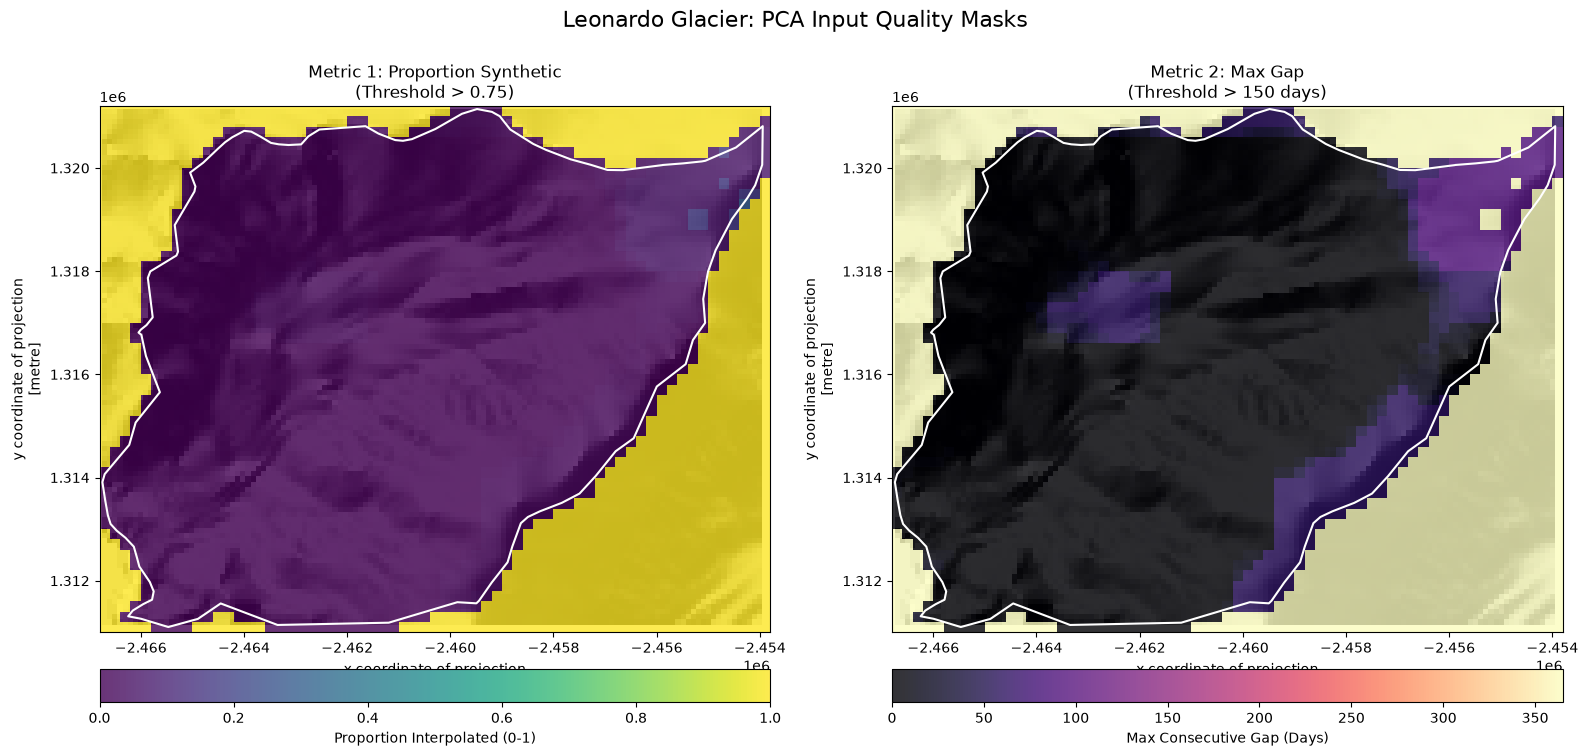

Displaying First 3 PCA Modes (in m/yr)...


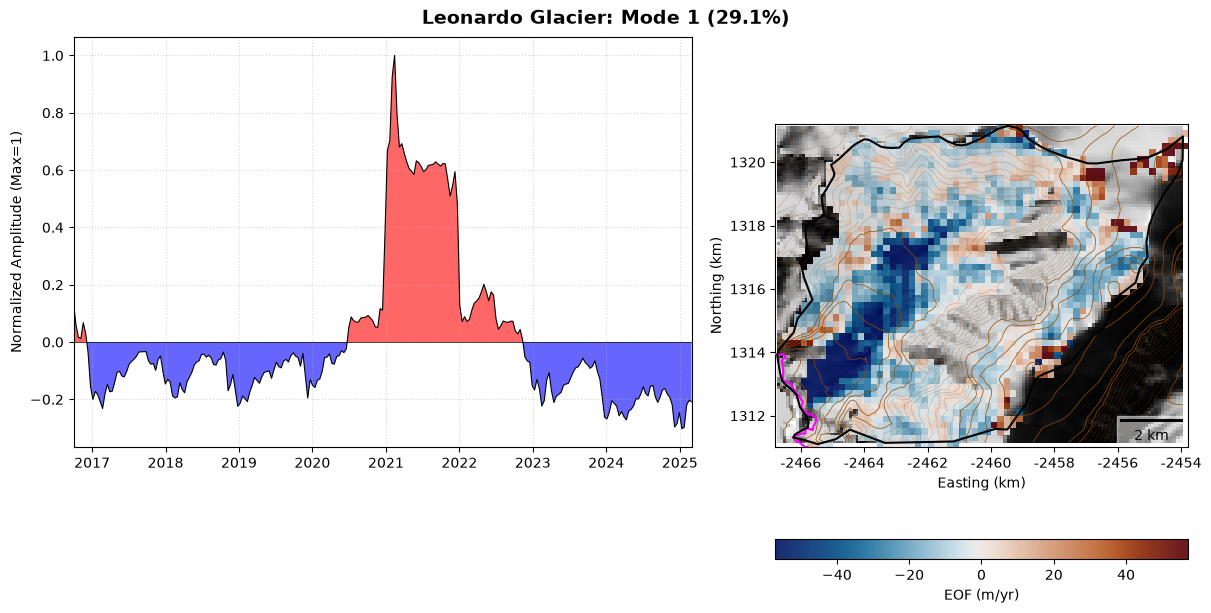

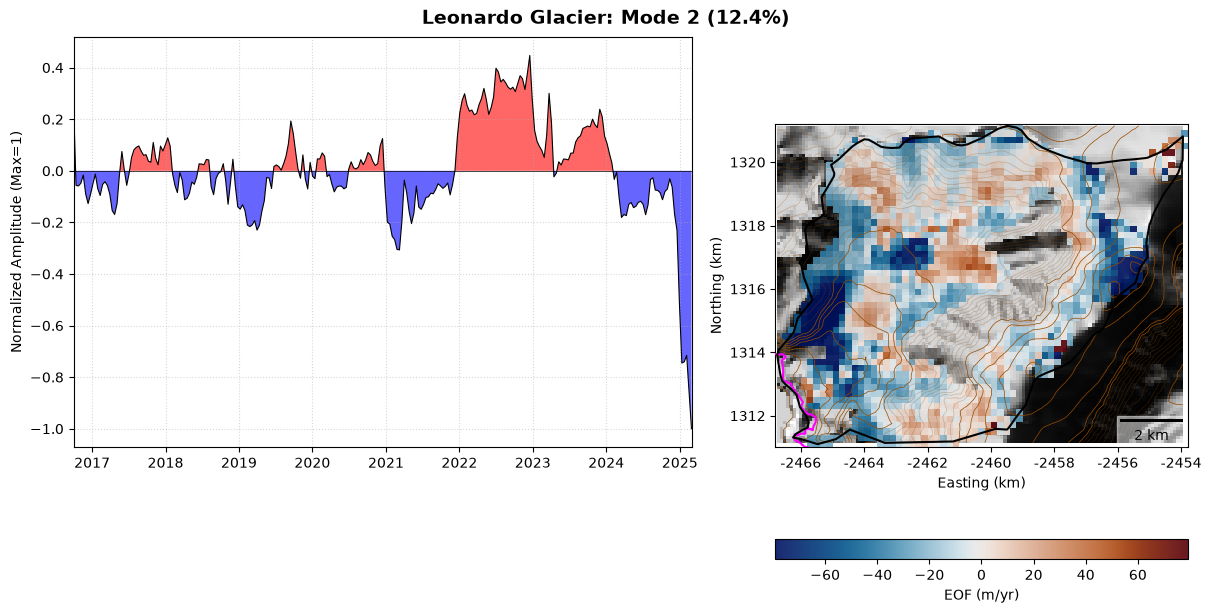

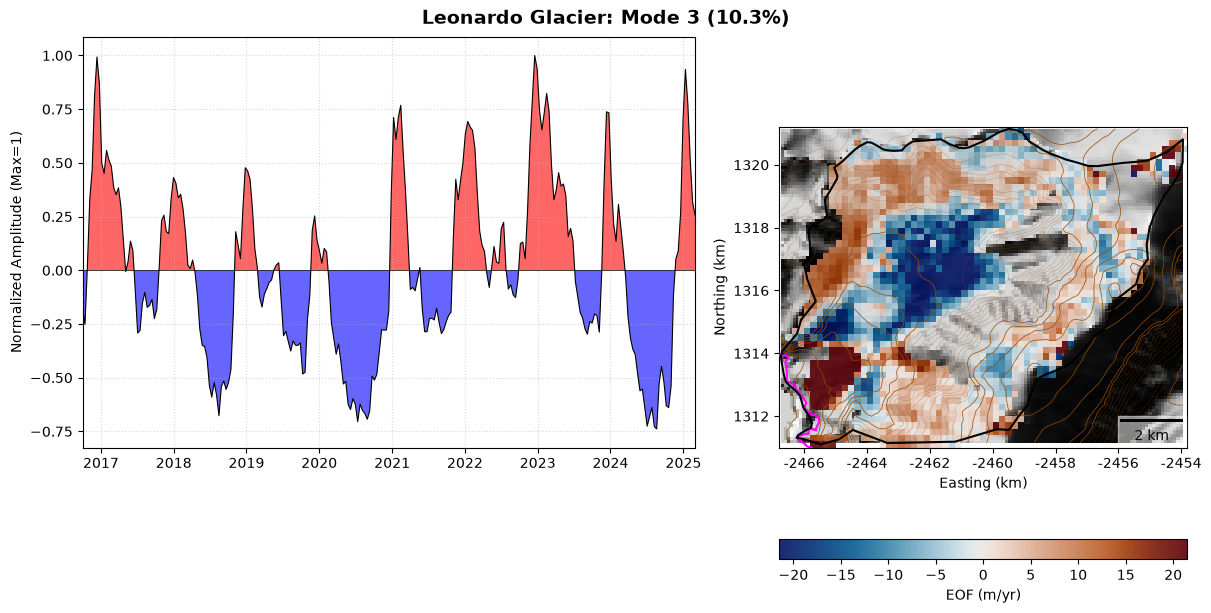

In [9]:
if da_clean.pixel.size >= 1000:
    print("Displaying Input Quality Maps...")
    dem_clip = rioxarray.open_rasterio(DEM_PATH).rio.clip_box(*basin_geom.bounds).isel(band=0)
    gl_vectors = gpd.read_file(GL_PATH)
    gl_clip = gl_vectors.cx[basin_geom.bounds[0]:basin_geom.bounds[2], basin_geom.bounds[1]:basin_geom.bounds[3]]

    plot_quality_map(prop_filled_map, max_gap_map, dem_clip, basin_geom, TARGET_BASIN)

    print("Displaying First 3 PCA Modes (in m/yr)...")
    for m in range(NUM_MODES):
        mode_idx = m + 1
        var_exp = da_var.sel(mode=mode_idx).item()
        pc_series = da_pcs.sel(mode=mode_idx)
        eof_map = da_eofs.sel(mode=mode_idx)
        
        plot_mode_figure(
            mode_idx, var_exp, pc_series, eof_map, dem_clip, gl_clip, basin_geom, TARGET_BASIN
        )

This analysis confirms that Leonardo Glacier undergoes significant seasonal flow variability that is highly synchronized across its fast-flowing main trunk. Breaking this down, Mode 1 captures a broad multi-year trend—highlighted by a prolonged period of minimum speeds from mid-2020 through 2022—with a low-amplitude seasonal signal superimposed. Meanwhile, Mode 3 isolates a higher-amplitude seasonal cycle with a distinct spatial divide: speed peaks during the summer at the glacier terminus, whereas speeds peak during the winter at higher elevations.